In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
from pybiomart import Dataset

sc.settings.verbosity = 3
sc.settings.figdir = '/rds/general/user/ys5320/home/scrna_project/figures/'

RESULTS_DIR = '/rds/general/user/ys5320/home/scrna_project/results/'
GARDNER_DIR = '/rds/general/user/ys5320/home/scrna_project/data/gardner2024_celllines/'
GAMBARDELLA_DIR = '/rds/general/user/ys5320/home/scrna_project/data/gambardella2022_celllines/'

In [2]:
# CMO to cell line mapping from GEO metadata
cmo_map = {
    '1': 'BT474',
    '2': 'MDA-MB-453',
    '3': 'HCC38',
    '4': 'MDA-MB-231',
    '5': 'Hs578T',
    '6': 'MDA-MB-436'
}

# load
barcodes1 = pd.read_csv(GARDNER_DIR + 'GSE268249_barcodes.tsv.gz', 
                         header=None, compression='gzip')
features1 = pd.read_csv(GARDNER_DIR + 'GSE268249_features.tsv.gz',
                         header=None, sep='\t', compression='gzip')
adata1 = sc.read_mtx(GARDNER_DIR + 'GSE268249_matrix.mtx.gz').T

# assign names
gene_features1 = features1[features1[2] == 'Gene Expression']
adata1 = adata1[:, :len(gene_features1)].copy()
adata1.var_names = gene_features1[1].values.astype(str)
adata1.obs_names = barcodes1[0].values.astype(str)

# assign cell line from CMO suffix
adata1.obs['cell_line'] = adata1.obs_names.str.split('-').str[1].map(cmo_map)
adata1.obs['dataset'] = 'Gardner2024'

# keep only PhD-relevant cell lines
phd_lines1 = ['MDA-MB-231', 'BT474', 'Hs578T']
adata1 = adata1[adata1.obs['cell_line'].isin(phd_lines1)].copy()
adata1.var_names_make_unique()

print(f"Gardner loaded: {adata1.n_obs} cells x {adata1.n_vars} genes")
print(adata1.obs['cell_line'].value_counts())

Gardner loaded: 7912 cells x 36601 genes
cell_line
BT474         2954
MDA-MB-231    2670
Hs578T        2288
Name: count, dtype: int64


/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
# load Ensembl to gene name mapping
dataset_bm = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')
gene_map = dataset_bm.query(attributes=['ensembl_gene_id', 'external_gene_name'])
gene_map.columns = ['ensembl_id', 'gene_name']
gene_map = gene_map.drop_duplicates('ensembl_id').set_index('ensembl_id')

# load
barcodes2 = pd.read_csv(GAMBARDELLA_DIR + 'barcodes.tsv.gz', 
                         header=None, compression='gzip')
features2 = pd.read_csv(GAMBARDELLA_DIR + 'features.tsv.gz',
                         header=None, compression='gzip')
adata2 = sc.read_mtx(GAMBARDELLA_DIR + 'matrix.mtx.gz').T

# assign barcodes
adata2.obs_names = barcodes2[0].values.astype(str)
adata2.obs['cell_line_raw'] = barcodes2[0].str.split('_').str[0].values

# map ensembl IDs to gene names
mapped_names = []
for eid in features2[0].values:
    if eid in gene_map.index:
        name = gene_map.loc[eid, 'gene_name']
        mapped_names.append(str(name) if name != '' else str(eid))
    else:
        mapped_names.append(str(eid))

adata2.var_names = pd.Index(mapped_names)
adata2.var_names_make_unique()
adata2.obs['dataset'] = 'Gambardella2022'

# standardise cell line names and filter to PhD lines
name_map = {
    'MDAMB468': 'MDA-MB-468',
    'T47D': 'T47D',
    'CAL51': 'CAL51',
    'BT474': 'BT474',
    'HS578T': 'Hs578T'
}
phd_lines2 = list(name_map.keys())
adata2 = adata2[adata2.obs['cell_line_raw'].isin(phd_lines2)].copy()
adata2.obs['cell_line'] = adata2.obs['cell_line_raw'].map(name_map)

print(f"Gambardella loaded: {adata2.n_obs} cells x {adata2.n_vars} genes")
print(adata2.obs['cell_line'].value_counts())

Gambardella loaded: 6695 cells x 47096 genes
cell_line
BT474         2158
MDA-MB-468    1573
CAL51         1260
Hs578T         879
T47D           825
Name: count, dtype: int64


In [4]:
for adata, name in [(adata1, 'Gardner'), (adata2, 'Gambardella')]:
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'],
                                percent_top=None, log1p=False, inplace=True)
    print(f"\n=== {name} QC ===")
    print(f"Before filtering: {adata.n_obs}")
    print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())


=== Gardner QC ===
Before filtering: 7912
       n_genes_by_counts   total_counts  pct_counts_mt
count        7912.000000    7912.000000    7912.000000
mean         5618.716633   33585.031250      13.838125
std          1768.889339   18068.904297      15.686669
min           130.000000     665.000000       0.019172
25%          4896.750000   23127.000000       5.417398
50%          5811.000000   30605.000000       8.545681
75%          6739.000000   42054.250000      15.493721
max         10399.000000  135297.000000      96.806145

=== Gambardella QC ===
Before filtering: 6695
       n_genes_by_counts  total_counts  pct_counts_mt
count        6695.000000   6695.000000         6695.0
mean         3029.858701   8646.518555            0.0
std           759.987860   4341.536133            0.0
min          1695.000000   3687.000000            0.0
25%          2463.000000   5804.500000            0.0
50%          2845.000000   7357.000000            0.0
75%          3428.000000  10146.00000

In [5]:
def qc_filter(adata, min_genes=200, max_genes=8000, max_mito=20):
    adata = adata[adata.obs['n_genes_by_counts'] > min_genes, :]
    adata = adata[adata.obs['n_genes_by_counts'] < max_genes, :]
    adata = adata[adata.obs['pct_counts_mt'] < max_mito, :]
    return adata.copy()

adata1 = qc_filter(adata1)
adata2 = qc_filter(adata2)

print(f"Gardner after QC: {adata1.n_obs} cells")
print(f"Gambardella after QC: {adata2.n_obs} cells")

# save filtered objects with consistent naming
adata1.write(RESULTS_DIR + 'gardner2024_filtered.h5ad')
adata2.write(RESULTS_DIR + 'gambardella2022_filtered.h5ad')
print("Saved!")

Gardner after QC: 6364 cells
Gambardella after QC: 6693 cells
Saved!


In [6]:
# find common genes
common_genes = adata1.var_names.intersection(adata2.var_names)
print(f"Common genes: {len(common_genes)}")

# check ion channels
for gene in ['ANO1', 'KCNN4', 'CACNA1C', 'CACNA1H', 'SCN5A', 'SCN9A']:
    print(f"{gene}: {'✓' if gene in common_genes else '✗'}")

# subset and merge
adata1_c = adata1[:, common_genes].copy()
adata2_c = adata2[:, common_genes].copy()

adata_merged = ad.concat([adata1_c, adata2_c],
                          join='inner',
                          label='dataset',
                          keys=['Gardner2024', 'Gambardella2022'])

# assign electrical phenotype
adata_merged.obs['electrical_phenotype'] = adata_merged.obs['cell_line'].map({
    'MDA-MB-231': 'Blinker',
    'MDA-MB-468': 'Blinker',
    'BT474': 'Waver',
    'T47D': 'Waver',
    'CAL51': 'Waver',
    'Hs578T': 'Waver'
})

print(f"\nMerged: {adata_merged.n_obs} cells x {adata_merged.n_vars} genes")
print(adata_merged.obs['cell_line'].value_counts())
print(adata_merged.obs['electrical_phenotype'].value_counts())

# save merged
adata_merged.write(RESULTS_DIR + 'celllines_merged.h5ad')
print("Saved!")

Common genes: 21673
ANO1: ✓
KCNN4: ✓
CACNA1C: ✓
CACNA1H: ✓
SCN5A: ✓
SCN9A: ✓

Merged: 13057 cells x 21673 genes
cell_line
BT474         4421
Hs578T        2667
MDA-MB-231    2311
MDA-MB-468    1573
CAL51         1260
T47D           825
Name: count, dtype: int64
electrical_phenotype
Waver      9173
Blinker    3884
Name: count, dtype: int64
Saved!


In [7]:
# normalise
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)
adata_merged.raw = adata_merged  # save all genes for DEG later

print("Normalisation done!")

normalizing counts per cell
    finished (0:00:01)
Normalisation done!


filtered out 4227 genes that are detected in less than 10 cells
Genes after filtering: 17446


/rds/general/user/ys5320/home/anaconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:39)


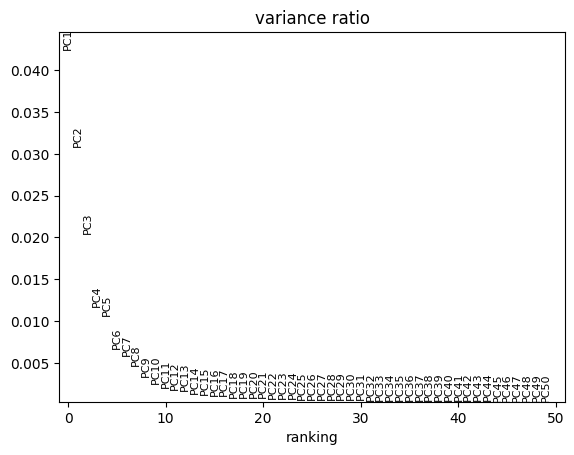

PCA done!


In [8]:
# remove lowly expressed genes
sc.pp.filter_genes(adata_merged, min_cells=10)
print(f"Genes after filtering: {adata_merged.n_vars}")

# scale and PCA
sc.pp.scale(adata_merged, max_value=10)
sc.tl.pca(adata_merged, svd_solver='arpack', n_comps=50)
sc.pl.pca_variance_ratio(adata_merged, n_pcs=50, 
                          save='_merged_pca_variance.png')
print("PCA done!")

In [11]:
import harmonypy as hm

# use both dataset and cell_line as batch variables
# BT474 and Hs578T in both datasets serve as anchors
ho = hm.run_harmony(
    adata_merged.obsm['X_pca'].astype(np.float64),
    adata_merged.obs,
    ['dataset', 'cell_line']
)
adata_merged.obsm['X_pca_harmony'] = ho.Z_corr.astype(np.float64)
print("Harmony done!")

2026-05-04 11:11:47,256 - harmonypy - INFO - Running Harmony
2026-05-04 11:11:47,256 - harmonypy - INFO -   Parameters:
2026-05-04 11:11:47,257 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-04 11:11:47,257 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-04 11:11:47,257 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-04 11:11:47,258 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-04 11:11:47,258 - harmonypy - INFO -     nclust: 100
2026-05-04 11:11:47,258 - harmonypy - INFO -     block_size: 0.05
2026-05-04 11:11:47,259 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-04 11:11:47,259 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-04 11:11:47,260 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-04 11:11:47,260 - harmonypy - INFO -     verbose: True
2026-05-04 11:11:47,260 - harmonypy - INFO -     random_state: 0
2026-05-04 11:11:47,261 - harmonypy - INFO -   Data: 50 PCs × 13057 cells
2026-05-04 11:11:47,261 - harmon

Harmony done!


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:33)
running Leiden clustering
    finished: found 13 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


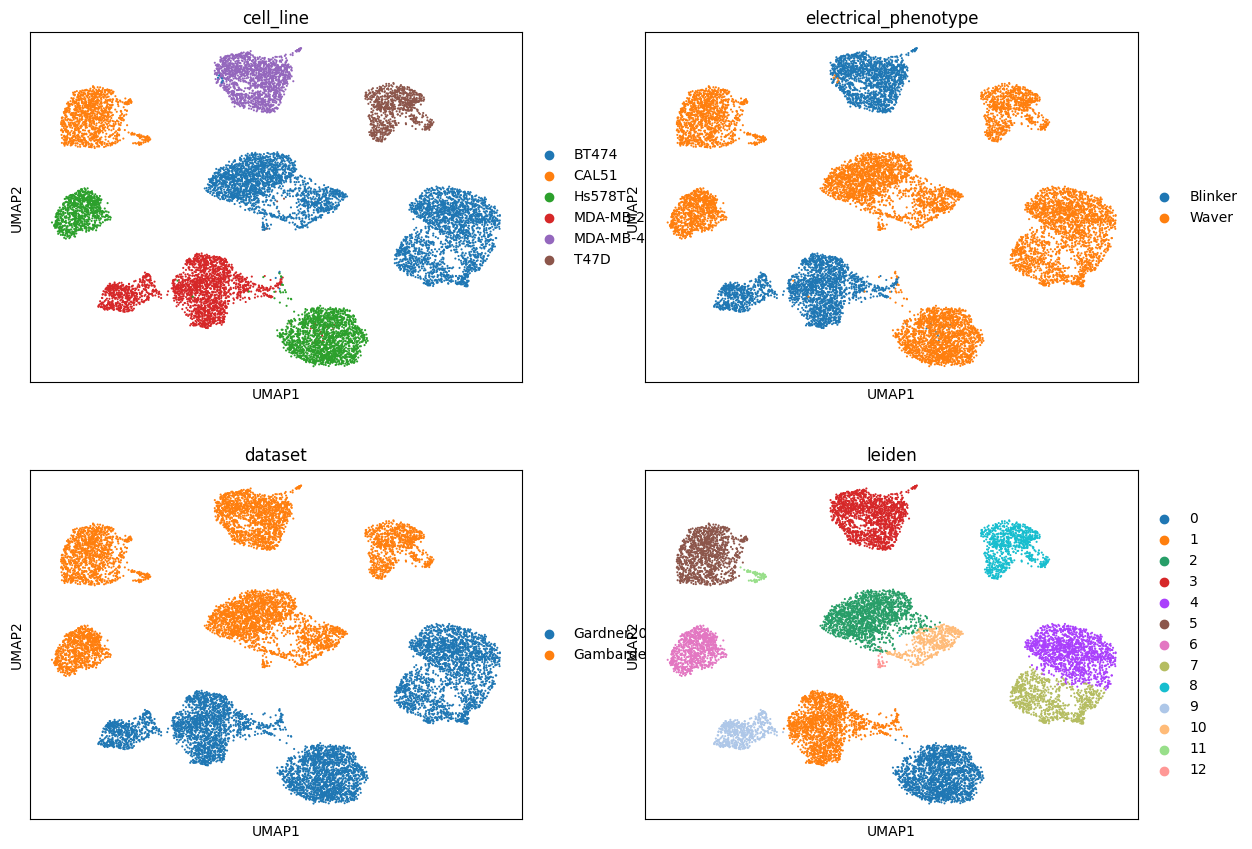

In [12]:
sc.pp.neighbors(adata_merged, n_neighbors=15, n_pcs=30,
                use_rep='X_pca_harmony')
sc.tl.umap(adata_merged)
sc.tl.leiden(adata_merged, resolution=0.3, key_added='leiden')

sc.pl.umap(adata_merged,
           color=['cell_line', 'electrical_phenotype', 'dataset', 'leiden'],
           ncols=2,
           save='_umap_merged_v2.png')

In [13]:
import scvi

# prepare data for scVI
# scVI needs raw counts, not normalised
# reload merged object before normalisation
adata_scvi = ad.concat([adata1[:, common_genes].copy(), 
                         adata2[:, common_genes].copy()],
                        join='inner',
                        label='dataset',
                        keys=['Gardner2024', 'Gambardella2022'])

# add metadata back
adata_scvi.obs['electrical_phenotype'] = adata_scvi.obs['cell_line'].map({
    'MDA-MB-231': 'Blinker',
    'MDA-MB-468': 'Blinker',
    'BT474': 'Waver',
    'T47D': 'Waver',
    'CAL51': 'Waver',
    'Hs578T': 'Waver'
})

# filter genes
sc.pp.filter_genes(adata_scvi, min_cells=10)
print(f"Genes: {adata_scvi.n_vars}")
print(f"Cells: {adata_scvi.n_obs}")

# setup scVI — specify batch key
scvi.model.SCVI.setup_anndata(adata_scvi, batch_key='dataset')

# create model
model = scvi.model.SCVI(adata_scvi, n_layers=2, n_latent=30)

print("scVI model created!")
print(model)

filtered out 4227 genes that are detected in less than 10 cells
Genes: 17446
Cells: 13057
scVI model created!


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

AnnData object with n_obs × n_vars = 13057 × 17446
    obs: 'cell_line', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'electrical_phenotype', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'neighbors', 'umap'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'connectivities', 'distances'
['cell_line', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'electrical_phenotype', '_scvi_batch', '_scvi_labels', 'leiden']


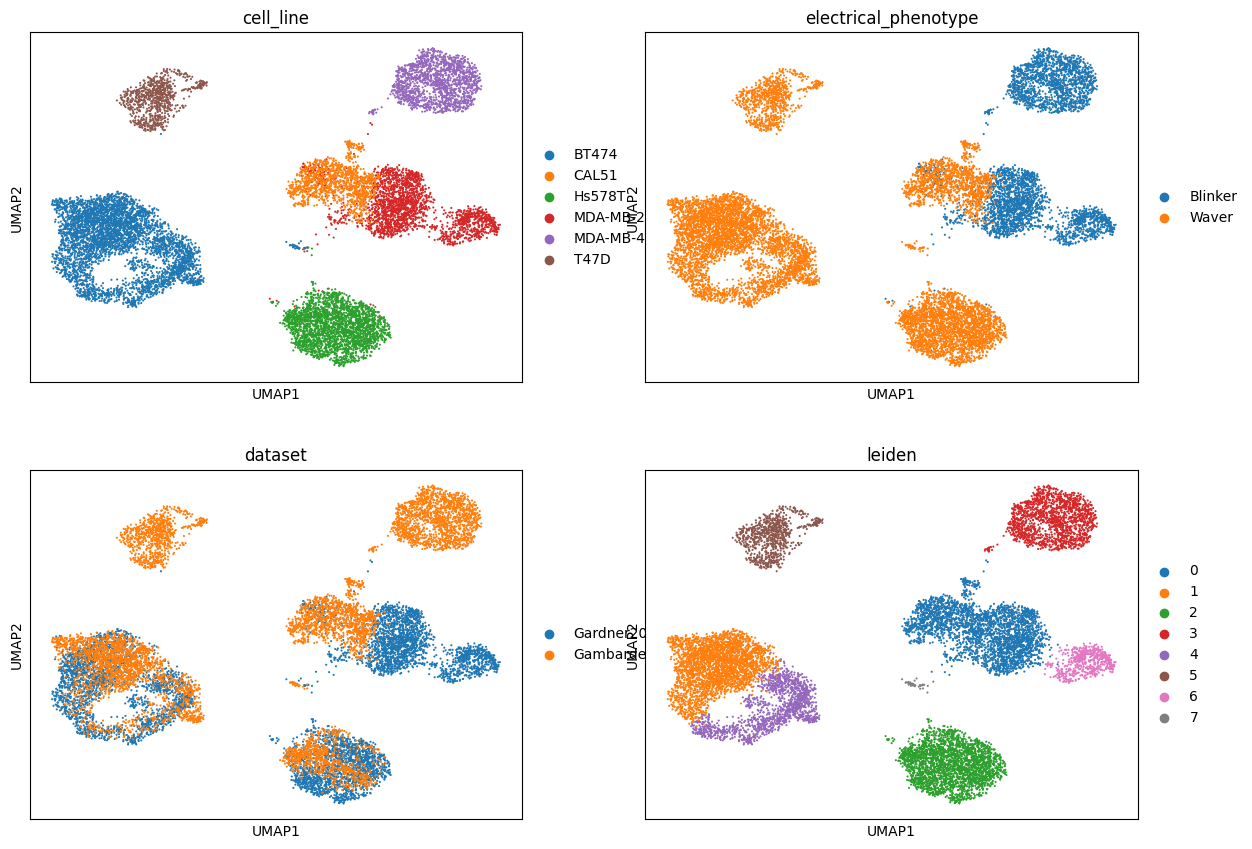

In [16]:
adata_scvi = sc.read_h5ad(RESULTS_DIR + 'celllines_scvi.h5ad')

print(adata_scvi)
print(adata_scvi.obs.columns.tolist())

sc.pl.umap(adata_scvi,
           color=['cell_line', 'electrical_phenotype', 'dataset', 'leiden'],
           ncols=2,
           save='_umap_scvi.png')

In [18]:
# normalise the scvi object for DEG
adata_deg = adata_scvi.copy()
sc.pp.normalize_total(adata_deg, target_sum=1e4)
sc.pp.log1p(adata_deg)

# now run DEG on normalised data
sc.tl.rank_genes_groups(adata_deg,
                         groupby='electrical_phenotype',
                         groups=['Blinker'],
                         reference='Waver',
                         method='wilcoxon',
                         key_added='deg_blinker_vs_waver')

result = adata_deg.uns['deg_blinker_vs_waver']
deg_df = pd.DataFrame({
    'gene': result['names']['Blinker'],
    'score': result['scores']['Blinker'],
    'pval': result['pvals']['Blinker'],
    'pval_adj': result['pvals_adj']['Blinker'],
    'logfoldchange': result['logfoldchanges']['Blinker']
})

sig_deg = deg_df[deg_df['pval_adj'] < 0.05].copy()
print(f"Significant DEGs: {len(sig_deg)}")
print(f"\nTop 10 upregulated in Blinker:")
print(sig_deg.nlargest(10, 'score')[['gene', 'score', 'logfoldchange', 'pval_adj']])
print(f"\nTop 10 downregulated in Blinker:")
print(sig_deg.nsmallest(10, 'score')[['gene', 'score', 'logfoldchange', 'pval_adj']])

sig_deg.to_csv(RESULTS_DIR + 'deg_blinker_vs_waver.csv', index=False)

normalizing counts per cell
    finished (0:00:01)
ranking genes
    finished: added to `.uns['deg_blinker_vs_waver']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)
Significant DEGs: 10660

Top 10 upregulated in Blinker:
      gene      score  logfoldchange  pval_adj
0     KLK5  84.148651       8.160352       0.0
1    KRT81  83.266624       7.664202       0.0
2  S100A10  73.929054       1.865172       0.0
3     RPL5  67.033318       0.877792       0.0
4    HLA-A  66.250458       2.436375       0.0
5    ANXA2  65.570381       1.470099       0.0
6   S100A9  64.837898       4.867069       0.0
7      BID  64.485458       2.252996       0.0
8     CYBA  64.403320       3.587250       0.0
9  RARRES1  63.825268       3.983102

In [19]:
import gseapy as gp

ranked_genes = deg_df.set_index('gene')['score'].sort_values(ascending=False)

gsea_results = gp.prerank(
    rnk=ranked_genes,
    gene_sets='MSigDB_Hallmark_2020',
    threads=4,
    min_size=15,
    max_size=500,
    permutation_num=100,
    outdir=RESULTS_DIR + 'gsea_blinker_vs_waver',
    seed=42,
    verbose=False
)

gsea_df = gsea_results.res2d
print(gsea_df[['Term', 'NES', 'NOM p-val', 'FDR q-val']].head(20))
gsea_df.to_csv(RESULTS_DIR + 'gsea_blinker_vs_waver.csv', index=False)

2026-05-05 11:04:07,626 [WARNING] Duplicated values found in preranked stats: 2.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


                                 Term       NES  NOM p-val  FDR q-val
0                         E2F Targets  1.814619   0.010000   0.010000
1                     G2-M Checkpoint  1.745048   0.010000   0.010000
2                      Myc Targets V1  1.717151   0.010000   0.010000
3                      Myc Targets V2  1.656199   0.010000   0.010000
4                        Angiogenesis -1.651773   0.010000   0.010000
5           Interferon Alpha Response  1.578732   0.010000   0.010000
6            IL-6/JAK/STAT3 Signaling  1.562241   0.010000   0.010000
7           Interferon Gamma Response   1.54758   0.010000   0.010000
8                      UV Response Dn -1.490246   0.010000   0.010000
9                 Allograft Rejection  1.430405   0.010417   0.044816
10                 TGF-beta Signaling  1.398336   0.021277   0.064599
11  Epithelial Mesenchymal Transition -1.370593   0.010000   0.037453
12      TNF-alpha Signaling via NF-kB  1.329306   0.010000   0.136628
13                  

In [21]:
# save final results
adata_scvi.write(RESULTS_DIR + 'celllines_final.h5ad')
deg_df.to_csv(RESULTS_DIR + 'deg_blinker_vs_waver_final.csv', index=False)
gsea_df.to_csv(RESULTS_DIR + 'gsea_blinker_vs_waver_final.csv', index=False)
print("All results saved!")

All results saved!


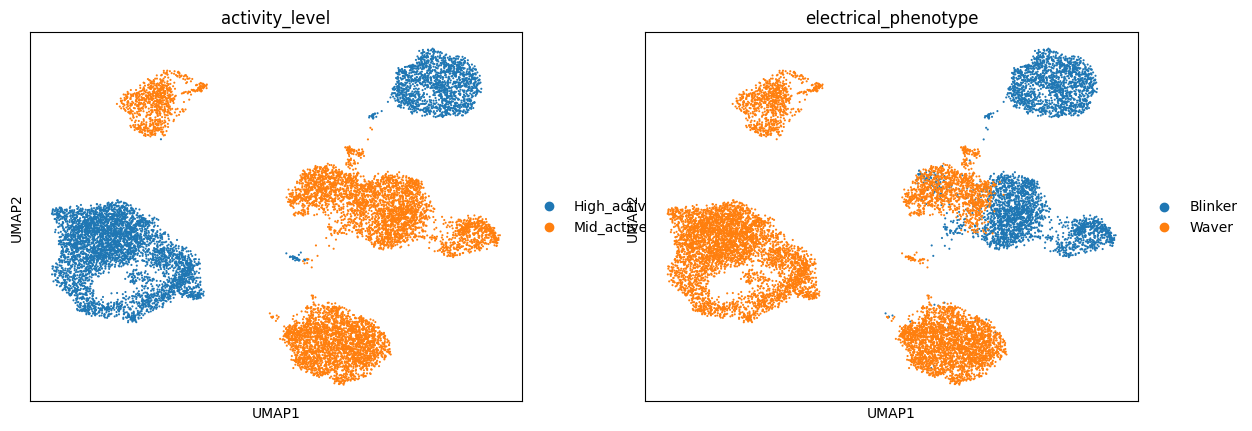

In [22]:
# add activity level to scvi object for UMAP
adata_scvi.obs['activity_level'] = adata_scvi.obs['cell_line'].map({
    'BT474': 'High_active',
    'MDA-MB-468': 'High_active',
    'MDA-MB-231': 'Mid_active',
    'Hs578T': 'Mid_active',
    'T47D': 'Mid_active',
    'CAL51': 'Mid_active'
})

sc.pl.umap(adata_scvi,
           color=['activity_level', 'electrical_phenotype'],
           ncols=2,
           save='_umap_activity_vs_phenotype.png')

In [23]:
# add activity level to deg object
adata_deg.obs['activity_level'] = adata_scvi.obs['activity_level']

print(adata_deg.obs['activity_level'].value_counts())

# DEG high vs mid active
sc.tl.rank_genes_groups(adata_deg,
                         groupby='activity_level',
                         groups=['High_active'],
                         reference='Mid_active',
                         method='wilcoxon',
                         key_added='deg_high_vs_mid')

result2 = adata_deg.uns['deg_high_vs_mid']
deg_df2 = pd.DataFrame({
    'gene': result2['names']['High_active'],
    'score': result2['scores']['High_active'],
    'pval': result2['pvals']['High_active'],
    'pval_adj': result2['pvals_adj']['High_active'],
    'logfoldchange': result2['logfoldchanges']['High_active']
})

sig_deg2 = deg_df2[deg_df2['pval_adj'] < 0.05].copy()
print(f"Significant DEGs: {len(sig_deg2)}")
print(f"\nTop 10 upregulated in High_active:")
print(sig_deg2.nlargest(10, 'score')[['gene', 'score', 'logfoldchange', 'pval_adj']])
print(f"\nTop 10 downregulated in High_active:")
print(sig_deg2.nsmallest(10, 'score')[['gene', 'score', 'logfoldchange', 'pval_adj']])

deg_df2.to_csv(RESULTS_DIR + 'deg_high_vs_mid_active.csv', index=False)

activity_level
Mid_active     7063
High_active    5994
Name: count, dtype: int64
ranking genes
    finished: added to `.uns['deg_high_vs_mid']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)
Significant DEGs: 11351

Top 10 upregulated in High_active:
      gene      score  logfoldchange  pval_adj
0     RPS3  92.250351       1.355922       0.0
1   STOML2  88.776276       2.341873       0.0
2    FXYD3  88.118111       4.470379       0.0
3  S100A14  86.763512       3.633549       0.0
4      VCP  83.180138       2.085967       0.0
5    AP1M2  80.494171       4.270367       0.0
6    PFDN4  80.219894       2.751311       0.0
7    TSTD1  80.079117       3.091761       0.0
8    RPL19  79.970474       2.800692       0.0
9    PS

In [24]:
ranked_genes2 = deg_df2.set_index('gene')['score'].sort_values(ascending=False)

gsea_results2 = gp.prerank(
    rnk=ranked_genes2,
    gene_sets='MSigDB_Hallmark_2020',
    threads=4,
    min_size=15,
    max_size=500,
    permutation_num=100,
    outdir=RESULTS_DIR + 'gsea_high_vs_mid_active',
    seed=42,
    verbose=False
)

gsea_df2 = gsea_results2.res2d
print(gsea_df2[['Term', 'NES', 'NOM p-val', 'FDR q-val']].head(20))
gsea_df2.to_csv(RESULTS_DIR + 'gsea_high_vs_mid_active.csv', index=False)


2026-05-05 11:18:39,239 [WARNING] Duplicated values found in preranked stats: 2.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


                                 Term       NES  NOM p-val  FDR q-val
0   Epithelial Mesenchymal Transition -2.130969   0.010000   0.010000
1                        Angiogenesis -1.927875   0.010000   0.010000
2                     G2-M Checkpoint  -1.71489   0.010000   0.010000
3             Estrogen Response Early   1.65047   0.010000   0.023188
4                         Coagulation -1.639855   0.010000   0.010000
5                          Complement  -1.63103   0.010000   0.010000
6                     Apical Junction -1.612641   0.010000   0.010000
7              Estrogen Response Late  1.611319   0.010000   0.011594
8           Unfolded Protein Response -1.604332   0.010000   0.010000
9                 Allograft Rejection -1.572071   0.010000   0.010000
10                     UV Response Dn -1.544545   0.010000   0.010000
11                 TGF-beta Signaling -1.544374   0.022989   0.010000
12                        E2F Targets -1.537051   0.010000   0.010000
13                  